# FIFA World Cup 2026 Prediction Competition

This notebook builds an end-to-end prediction pipeline for the FIFA World Cup 2026 competition. It reads the local competition files, downloads public football data, engineers national-team strength features, trains separate models for goals, outcomes, corners, yellow cards, and red cards, ensembles model predictions, simulates the tournament 10,000 times, and writes submission-ready group and knockout prediction files.

The notebook is designed to run top to bottom. Optional sources and optional modeling libraries have fallbacks so temporary source outages do not break the workflow.

## 1. Introduction

### Objective
Predict every scheduled 2026 World Cup group fixture and populate every knockout slot with likely teams, scorelines, discipline totals, corner totals, winners, and penalty flags.

### Methodology
The pipeline combines historical international results, FIFA ranking history, World Cup match data, World Cup booking data, penalty-shootout data, and optional Football-Data.co.uk match-stat feeds. It uses rolling team form, Elo ratings, FIFA rankings, tournament experience, head-to-head records, venue advantage, and recent tournament performance.

Separate supervised models are trained for home goals, away goals, match outcome, corners, yellow cards, and red cards. Predictions are ensembled with cross-validated inverse-error weights, then the full tournament is simulated probabilistically.

### Assumptions
Fixture placeholders such as UEFA Playoff A and FIFA Playoff 1 are retained as valid teams and receive synthetic profiles based on confederation or global-average priors. Corners are not consistently available for historical international matches, so the corners model uses Football-Data.co.uk priors where available and a conservative international-match proxy target. Yellow and red cards are calibrated from historical World Cup booking data when available.

## 2. Reproducible Setup

This cell installs missing packages when needed. XGBoost and LightGBM are attempted because they are part of the requested model comparison, but the notebook falls back to scikit-learn models if either package is unavailable.

In [1]:
import importlib.util
import math
import os
import random
import re
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from functools import lru_cache
from pathlib import Path

INSTALL_MISSING_PACKAGES = True
RANDOM_SEED = 42
N_SIMULATIONS = 10_000

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "plotly": "plotly",
    "requests": "requests",
    "tqdm": "tqdm",
}
OPTIONAL_PACKAGES = {"xgboost": "xgboost", "lightgbm": "lightgbm"}


def ensure_package(module_name, package_name, required=True):
    if importlib.util.find_spec(module_name) is not None:
        return True
    if not INSTALL_MISSING_PACKAGES:
        if required:
            raise ImportError(f"Missing required package: {package_name}")
        warnings.warn(f"Optional package unavailable: {package_name}")
        return False
    try:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", package_name])
        return importlib.util.find_spec(module_name) is not None
    except Exception as exc:
        if required:
            raise ImportError(f"Could not install required package {package_name}: {exc}") from exc
        warnings.warn(f"Optional package {package_name} could not be installed: {exc}")
        return False


for module_name, package_name in REQUIRED_PACKAGES.items():
    ensure_package(module_name, package_name, required=True)

HAS_XGBOOST = ensure_package("xgboost", "xgboost", required=False)
HAS_LIGHTGBM = ensure_package("lightgbm", "lightgbm", required=False)

import bisect
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, log_loss, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

if HAS_XGBOOST:
    from xgboost import XGBClassifier, XGBRegressor
else:
    XGBClassifier = None
    XGBRegressor = None

if HAS_LIGHTGBM:
    from lightgbm import LGBMClassifier
else:
    LGBMClassifier = None

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
EXTERNAL_DIR = DATA_DIR / "external"
OUTPUT_DIR = ROOT / "outputs"
for directory in [DATA_DIR, EXTERNAL_DIR, OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Workspace: {ROOT}")
print(f"XGBoost available: {HAS_XGBOOST}")
print(f"LightGBM available: {HAS_LIGHTGBM}")
print(f"Tournament simulations: {N_SIMULATIONS:,}")

Installing lightgbm...



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Workspace: /work/files/workspace
XGBoost available: True
LightGBM available: True
Tournament simulations: 10,000


## 3. Data Loading

The notebook loads local competition files and downloads public data from:

- `martj42/international_results` for historical international results and shootouts.
- Open FIFA ranking history mirrors plus an optional official FIFA ranking table scrape.
- `jfjelstul/worldcup` for World Cup matches, bookings, penalty kicks, and standings.
- Football-Data.co.uk optional league match-stat CSV files, used only to calibrate event priors.

All downloads are cached under `data/external`.

In [3]:
GROUP_FIXTURES_PATH = ROOT / "data/group_fixtures.csv"
KNOCKOUT_SLOTS_PATH = ROOT / "data/knockout_slots.csv"

if not GROUP_FIXTURES_PATH.exists():
    raise FileNotFoundError("group_fixtures.csv was not found in the working directory")
if not KNOCKOUT_SLOTS_PATH.exists():
    raise FileNotFoundError("knockout_slots.csv was not found in the working directory")

group_fixtures = pd.read_csv(GROUP_FIXTURES_PATH)
knockout_slots = pd.read_csv(KNOCKOUT_SLOTS_PATH)

PUBLIC_SOURCES = {
    "international_results": "https://raw.githubusercontent.com/martj42/international_results/master/results.csv",
    "international_shootouts": "https://raw.githubusercontent.com/martj42/international_results/master/shootouts.csv",
    "fifa_rankings_cnc8": "https://raw.githubusercontent.com/cnc8/fifa-world-ranking/master/fifa_ranking-2020-12-10.csv",
    "fifa_rankings_dato": "https://raw.githubusercontent.com/Dato-Futbol/fifa-ranking/master/ranking_fifa_historical.csv",
    "worldcup_matches": "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/matches.csv",
    "worldcup_bookings": "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/bookings.csv",
    "worldcup_penalty_kicks": "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/penalty_kicks.csv",
    "worldcup_standings": "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/tournament_standings.csv",
}

HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; world-cup-2026-analytics-notebook/1.0)"}


def safe_read_csv_from_url(name, url, encoding="utf-8", required=False, timeout=25, **kwargs):
    cache_path = EXTERNAL_DIR / f"{name}.csv"
    try:
        response = requests.get(url, headers=HEADERS, timeout=timeout)
        response.raise_for_status()
        try:
            df = pd.read_csv(io.BytesIO(response.content), encoding=encoding, **kwargs)
        except Exception as parse_exc:
            if required:
                raise RuntimeError(f"Required source {name} downloaded but did not parse as CSV: {url}") from parse_exc
            print(f"Optional source skipped after parse issue: {name} ({parse_exc})")
            return pd.DataFrame()
        cache_path.write_bytes(response.content)
        print(f"Loaded {name}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")
        return df
    except Exception as exc:
        if cache_path.exists():
            try:
                print(f"Using cached {name} after download issue: {exc}")
                return pd.read_csv(cache_path, encoding=encoding, **kwargs)
            except Exception as cache_exc:
                if required:
                    raise RuntimeError(f"Required source {name} failed from download and cache") from cache_exc
                print(f"Optional source skipped after cache parse issue: {name} ({cache_exc})")
                return pd.DataFrame()
        if required:
            raise RuntimeError(f"Required source {name} failed: {url}") from exc
        print(f"Optional source skipped: {name} ({exc})")
        return pd.DataFrame()


external = {}
external["international_results"] = safe_read_csv_from_url("international_results", PUBLIC_SOURCES["international_results"], required=True)
external["international_shootouts"] = safe_read_csv_from_url("international_shootouts", PUBLIC_SOURCES["international_shootouts"])
external["fifa_rankings_cnc8"] = safe_read_csv_from_url("fifa_rankings_cnc8", PUBLIC_SOURCES["fifa_rankings_cnc8"])
external["fifa_rankings_dato"] = safe_read_csv_from_url("fifa_rankings_dato", PUBLIC_SOURCES["fifa_rankings_dato"])
external["worldcup_matches"] = safe_read_csv_from_url("worldcup_matches", PUBLIC_SOURCES["worldcup_matches"])
external["worldcup_bookings"] = safe_read_csv_from_url("worldcup_bookings", PUBLIC_SOURCES["worldcup_bookings"])
external["worldcup_penalty_kicks"] = safe_read_csv_from_url("worldcup_penalty_kicks", PUBLIC_SOURCES["worldcup_penalty_kicks"])
external["worldcup_standings"] = safe_read_csv_from_url("worldcup_standings", PUBLIC_SOURCES["worldcup_standings"])


def try_official_fifa_ranking_table():
    url = "https://inside.fifa.com/fifa-world-ranking/men"
    try:
        tables = pd.read_html(url)
        for table in tables:
            lower_cols = [str(c).lower() for c in table.columns]
            if any("team" in c or "country" in c for c in lower_cols) and any("rank" in c for c in lower_cols):
                table["rank_date"] = pd.Timestamp.today().normalize()
                print(f"Loaded optional official FIFA ranking table: {table.shape}")
                return table
    except Exception as exc:
        print(f"Official FIFA ranking table scrape skipped: {exc}")
    return pd.DataFrame()


external["fifa_rankings_official_optional"] = try_official_fifa_ranking_table()


def load_football_data_uk(seasons=("2526", "2425", "2324"), leagues=("E0", "SP1", "D1", "I1", "F1")):
    frames = []
    for season in seasons:
        for league in leagues:
            name = f"football_data_uk_{season}_{league}"
            url = f"https://www.football-data.co.uk/mmz4281/{season}/{league}.csv"
            df = safe_read_csv_from_url(name, url, encoding="latin1", timeout=8)
            if not df.empty:
                df["source_season"] = season
                df["source_league"] = league
                frames.append(df)
    if frames:
        combined = pd.concat(frames, ignore_index=True, sort=False)
        print(f"Football-Data.co.uk combined: {combined.shape}")
        return combined
    print("Football-Data.co.uk feeds unavailable; using conservative event priors.")
    return pd.DataFrame()


external["football_data_uk"] = load_football_data_uk()

print("Group fixtures:", group_fixtures.shape)
print("Knockout slots:", knockout_slots.shape)
display(group_fixtures.head())
display(knockout_slots.head())

Loaded international_results: 49,477 rows, 9 columns
Loaded international_shootouts: 678 rows, 5 columns
Loaded fifa_rankings_cnc8: 62,424 rows, 9 columns
Loaded fifa_rankings_dato: 67,894 rows, 6 columns
Loaded worldcup_matches: 1,248 rows, 37 columns
Loaded worldcup_bookings: 3,178 rows, 26 columns
Loaded worldcup_penalty_kicks: 396 rows, 19 columns
Loaded worldcup_standings: 120 rows, 7 columns
Loaded optional official FIFA ranking table: (0, 7)
Loaded football_data_uk_2526_E0: 380 rows, 132 columns
Loaded football_data_uk_2526_SP1: 380 rows, 131 columns
Loaded football_data_uk_2526_D1: 306 rows, 131 columns
Loaded football_data_uk_2526_I1: 380 rows, 131 columns
Loaded football_data_uk_2526_F1: 305 rows, 131 columns
Loaded football_data_uk_2425_E0: 380 rows, 120 columns
Loaded football_data_uk_2425_SP1: 380 rows, 119 columns
Loaded football_data_uk_2425_D1: 306 rows, 119 columns
Loaded football_data_uk_2425_I1: 380 rows, 119 columns
Loaded football_data_uk_2425_F1: 306 rows, 119 col

,match_id,group,home_team,away_team,date_utc,venue
0,1,A,Mexico,South Africa,2026-06-11T19:00:00Z,"Estadio Azteca, Mexico City"
1,2,A,South Korea,UEFA Playoff D,2026-06-12T02:00:00Z,"Estadio Akron, Guadalajara"
2,3,B,Canada,UEFA Playoff A,2026-06-12T19:00:00Z,"BMO Field, Toronto"
3,4,D,USA,Paraguay,2026-06-13T01:00:00Z,"SoFi Stadium, Los Angeles"
4,5,D,Australia,UEFA Playoff C,2026-06-13T04:00:00Z,"BC Place, Vancouver"


,match_id,round,multiplier,date_utc,venue,slot_home,slot_away
0,73,Round of 32,1,2026-06-28T19:00:00Z,"SoFi Stadium, Los Angeles",Runner-up Group A,Runner-up Group B
1,74,Round of 32,1,2026-06-29T17:00:00Z,"NRG Stadium, Houston",Winner Group C,Runner-up Group F
2,75,Round of 32,1,2026-06-29T20:30:00Z,"Gillette Stadium, Boston",Winner Group E,Best 3rd (Groups A/B/C/D/F)
3,76,Round of 32,1,2026-06-30T01:00:00Z,"Estadio BBVA, Monterrey",Winner Group F,Runner-up Group C
4,77,Round of 32,1,2026-06-30T17:00:00Z,"AT&T Stadium, Dallas",Runner-up Group E,Runner-up Group I


## 4. Data Cleaning

Cleaning includes missing-value handling, duplicate removal, team-name standardization, date conversion, score conversion, tournament labelling, and venue-host inference for home advantage.

In [4]:
TEXT_REPAIRS = {
    "Cura\u00c3\u00a7ao": "Cura\u00e7ao",
    "Curacao": "Cura\u00e7ao",
    "C\u00c3\u00b4te d'Ivoire": "C\u00f4te d'Ivoire",
    "Cote d'Ivoire": "C\u00f4te d'Ivoire",
    "Ivory Coast": "C\u00f4te d'Ivoire",
}

TEAM_ALIASES = {
    "United States": "USA",
    "United States of America": "USA",
    "Korea Republic": "South Korea",
    "Republic of Korea": "South Korea",
    "Korea DPR": "North Korea",
    "Cape Verde": "Cabo Verde",
    "Czech Republic": "Czechia",
    "Swaziland": "Eswatini",
    "The Gambia": "Gambia",
    "Gambia, The": "Gambia",
    "Bosnia and Herzegovina": "Bosnia-Herzegovina",
    "Republic of Ireland": "Ireland",
    "China PR": "China",
    "IR Iran": "Iran",
    "T\u00fcrkiye": "Turkey",
    "Soviet Union": "Russia",
    "West Germany": "Germany",
    "German DR": "Germany",
    "Yugoslavia": "Serbia",
    "Serbia and Montenegro": "Serbia",
    "Zaire": "DR Congo",
    "Congo DR": "DR Congo",
}

MAJOR_TOURNAMENT_KEYWORDS = [
    "FIFA World Cup",
    "UEFA Euro",
    "European Championship",
    "Copa America",
    "Copa Am\u00e9rica",
    "African Cup of Nations",
    "Africa Cup of Nations",
    "AFC Asian Cup",
    "CONCACAF Gold Cup",
    "CONCACAF Championship",
    "Oceania Nations Cup",
    "UEFA Nations League",
]
CONTINENTAL_TOURNAMENT_KEYWORDS = [
    "UEFA Euro",
    "European Championship",
    "Copa America",
    "Copa Am\u00e9rica",
    "African Cup of Nations",
    "Africa Cup of Nations",
    "AFC Asian Cup",
    "CONCACAF Gold Cup",
    "CONCACAF Championship",
]


def repair_text(value):
    if pd.isna(value):
        return value
    text = str(value).strip()
    if not text:
        return text
    if text in TEXT_REPAIRS:
        return TEXT_REPAIRS[text]
    if "\u00c3" in text or "\ufffd" in text:
        try:
            repaired = text.encode("latin1").decode("utf-8")
            if "\u00c3" not in repaired and "\ufffd" not in repaired:
                text = repaired
        except Exception:
            pass
    return TEXT_REPAIRS.get(text, text)


def standardize_team_name(value):
    text = repair_text(value)
    if pd.isna(text):
        return text
    text = re.sub(r"\s+", " ", str(text).strip())
    return TEAM_ALIASES.get(text, text)


def parse_datetime_utc(series):
    return pd.to_datetime(series, errors="coerce", utc=True).dt.tz_convert(None)


def clean_bool(value, default=False):
    if pd.isna(value):
        return default
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {"true", "1", "yes", "y"}


def is_major_tournament(tournament):
    text = repair_text(tournament)
    if pd.isna(text):
        return False
    return any(keyword.lower() in str(text).lower() for keyword in MAJOR_TOURNAMENT_KEYWORDS)


def is_continental_tournament(tournament):
    text = repair_text(tournament)
    if pd.isna(text):
        return False
    return any(keyword.lower() in str(text).lower() for keyword in CONTINENTAL_TOURNAMENT_KEYWORDS)


def tournament_weight(tournament):
    text = str(repair_text(tournament)).lower()
    if "fifa world cup" in text:
        return 4.0
    if any(keyword.lower() in text for keyword in CONTINENTAL_TOURNAMENT_KEYWORDS):
        return 3.0
    if "qualification" in text or "qualifier" in text:
        return 2.0
    if "nations league" in text:
        return 1.8
    if "friendly" in text:
        return 1.0
    return 1.3


def venue_host_country(venue):
    text = str(repair_text(venue)).lower()
    if any(key in text for key in ["toronto", "vancouver", "bmo field", "bc place", "canada"]):
        return "Canada"
    if any(key in text for key in ["mexico city", "guadalajara", "monterrey", "azteca", "akron", "bbva", "mexico"]):
        return "Mexico"
    return "USA"


def host_advantage(team, venue_country):
    return int(standardize_team_name(team) == standardize_team_name(venue_country))


group_fixtures = group_fixtures.copy()
for col in ["home_team", "away_team"]:
    group_fixtures[col] = group_fixtures[col].map(standardize_team_name)
group_fixtures["date_utc"] = parse_datetime_utc(group_fixtures["date_utc"])
group_fixtures["venue"] = group_fixtures["venue"].map(repair_text).fillna("Unknown")
group_fixtures["venue_country"] = group_fixtures["venue"].map(venue_host_country)
group_fixtures = group_fixtures.drop_duplicates(subset=["match_id"]).reset_index(drop=True)

knockout_slots = knockout_slots.copy()
knockout_slots["date_utc"] = parse_datetime_utc(knockout_slots["date_utc"])
knockout_slots["venue"] = knockout_slots["venue"].map(repair_text).fillna("Unknown")
knockout_slots["venue_country"] = knockout_slots["venue"].map(venue_host_country)
knockout_slots = knockout_slots.drop_duplicates(subset=["match_id"]).sort_values("match_id").reset_index(drop=True)

intl = external["international_results"].copy()
for col in ["home_team", "away_team", "country"]:
    if col in intl.columns:
        intl[col] = intl[col].map(standardize_team_name)
intl["date"] = parse_datetime_utc(intl["date"])
intl["home_score"] = pd.to_numeric(intl["home_score"], errors="coerce")
intl["away_score"] = pd.to_numeric(intl["away_score"], errors="coerce")
intl["tournament"] = intl["tournament"].map(repair_text)
intl["neutral"] = intl["neutral"].map(lambda x: clean_bool(x, default=True))
intl = intl.dropna(subset=["date", "home_team", "away_team", "home_score", "away_score"])
intl = intl.drop_duplicates(subset=["date", "home_team", "away_team", "home_score", "away_score", "tournament"])
intl["home_score"] = intl["home_score"].astype(int)
intl["away_score"] = intl["away_score"].astype(int)
intl["is_major"] = intl["tournament"].map(is_major_tournament)
intl["is_continental"] = intl["tournament"].map(is_continental_tournament)
intl["tournament_weight"] = intl["tournament"].map(tournament_weight)

print("Cleaned international results:", intl.shape)
print("Date range:", intl["date"].min(), "to", intl["date"].max())
display(intl.tail())

Cleaned international results: (49404, 12)
Date range: 1872-11-30 00:00:00 to 2026-06-10 00:00:00


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,is_major,is_continental,tournament_weight
49400,2026-06-09,Iraq,Venezuela,0,2,Friendly,Bridgeview,USA,True,False,False,1.0
49401,2026-06-10,Bolivia,Algeria,0,4,Friendly,Kansas City,USA,True,False,False,1.0
49402,2026-06-10,England,Costa Rica,3,0,Friendly,Orlando,USA,True,False,False,1.0
49403,2026-06-10,Portugal,Nigeria,2,1,Friendly,Leiria,Portugal,False,False,False,1.0
49404,2026-06-10,Afghanistan,Pakistan,0,2,Diamond Jubilee International Football Tournament,Malé,Maldives,True,False,False,1.3


## 5. External Data Normalization

World Cup match, booking, penalty, FIFA ranking, and Football-Data.co.uk inputs are normalized into analytical tables. These tables feed tournament experience, discipline models, penalty priors, ranking features, and event priors.

In [5]:
def normalize_fifa_rankings(df):
    if df is None or df.empty:
        return pd.DataFrame(columns=["team", "rank", "total_points", "rank_date", "confederation"])
    data = df.copy()
    data.columns = [str(c).strip() for c in data.columns]
    lower_map = {str(c).lower(): c for c in data.columns}
    rename = {}
    if "country_full" in lower_map:
        rename[lower_map["country_full"]] = "team"
    elif "country" in lower_map:
        rename[lower_map["country"]] = "team"
    elif "team" in lower_map:
        rename[lower_map["team"]] = "team"
    for candidate in ["rank", "rk", "ranking"]:
        if candidate in lower_map:
            rename[lower_map[candidate]] = "rank"
            break
    for candidate in ["total_points", "points", "pts"]:
        if candidate in lower_map:
            rename[lower_map[candidate]] = "total_points"
            break
    if "rank_date" in lower_map:
        rename[lower_map["rank_date"]] = "rank_date"
    elif "date" in lower_map:
        rename[lower_map["date"]] = "rank_date"
    if "confederation" in lower_map:
        rename[lower_map["confederation"]] = "confederation"
    data = data.rename(columns=rename)
    if not {"team", "rank", "rank_date"}.issubset(set(data.columns)):
        return pd.DataFrame(columns=["team", "rank", "total_points", "rank_date", "confederation"])
    if "total_points" not in data.columns:
        data["total_points"] = np.nan
    if "confederation" not in data.columns:
        data["confederation"] = "Unknown"
    data = data[["team", "rank", "total_points", "rank_date", "confederation"]].copy()
    data["team"] = data["team"].map(standardize_team_name)
    data["rank"] = pd.to_numeric(data["rank"], errors="coerce")
    data["total_points"] = pd.to_numeric(data["total_points"], errors="coerce")
    data["rank_date"] = parse_datetime_utc(data["rank_date"])
    data = data.dropna(subset=["team", "rank", "rank_date"])
    data["total_points"] = data["total_points"].fillna(1000 + (220 - data["rank"]).clip(lower=0) * 4)
    return data.drop_duplicates(subset=["team", "rank_date"], keep="last")


ranking_frames = []
for source_name in ["fifa_rankings_cnc8", "fifa_rankings_dato", "fifa_rankings_official_optional"]:
    norm = normalize_fifa_rankings(external.get(source_name, pd.DataFrame()))
    if not norm.empty:
        norm["ranking_source"] = source_name
        ranking_frames.append(norm)

if ranking_frames:
    fifa_rankings = pd.concat(ranking_frames, ignore_index=True, sort=False)
    fifa_rankings = fifa_rankings.sort_values(["team", "rank_date", "ranking_source"])
    fifa_rankings = fifa_rankings.drop_duplicates(subset=["team", "rank_date"], keep="last")
else:
    fifa_rankings = pd.DataFrame(columns=["team", "rank", "total_points", "rank_date", "confederation", "ranking_source"])

wc_matches_raw = external["worldcup_matches"].copy()
if not wc_matches_raw.empty:
    wc_matches = wc_matches_raw.rename(
        columns={
            "match_date": "date",
            "home_team_name": "home_team",
            "away_team_name": "away_team",
            "home_team_score": "home_score",
            "away_team_score": "away_score",
        }
    ).copy()
    wc_matches["date"] = parse_datetime_utc(wc_matches["date"])
    wc_matches["home_team"] = wc_matches["home_team"].map(standardize_team_name)
    wc_matches["away_team"] = wc_matches["away_team"].map(standardize_team_name)
    wc_matches["home_score"] = pd.to_numeric(wc_matches["home_score"], errors="coerce")
    wc_matches["away_score"] = pd.to_numeric(wc_matches["away_score"], errors="coerce")
    wc_matches["tournament"] = "FIFA World Cup"
    wc_matches["neutral"] = True
    wc_matches["is_major"] = True
    wc_matches["is_continental"] = False
    wc_matches["tournament_weight"] = 4.0
    wc_matches = wc_matches.dropna(subset=["date", "home_team", "away_team", "home_score", "away_score"])
    wc_matches["home_score"] = wc_matches["home_score"].astype(int)
    wc_matches["away_score"] = wc_matches["away_score"].astype(int)
else:
    wc_matches = pd.DataFrame()

bookings_raw = external["worldcup_bookings"].copy()
if not bookings_raw.empty and "match_id" in bookings_raw.columns:
    for col in ["yellow_card", "red_card", "second_yellow_card", "sending_off"]:
        bookings_raw[col] = pd.to_numeric(bookings_raw.get(col, 0), errors="coerce").fillna(0)
    booking_counts = bookings_raw.groupby("match_id", as_index=False).agg(
        yellow_cards=("yellow_card", "sum"),
        red_cards=("sending_off", "sum"),
    )
else:
    booking_counts = pd.DataFrame(columns=["match_id", "yellow_cards", "red_cards"])

if not wc_matches.empty and not booking_counts.empty and "match_id" in wc_matches.columns:
    wc_event_matches = wc_matches.merge(booking_counts, on="match_id", how="left")
    wc_event_matches["yellow_cards"] = wc_event_matches["yellow_cards"].fillna(0)
    wc_event_matches["red_cards"] = wc_event_matches["red_cards"].fillna(0)
else:
    wc_event_matches = pd.DataFrame()

penalty_kicks = external["worldcup_penalty_kicks"].copy()
penalty_match_ids = set(penalty_kicks["match_id"].dropna().astype(str)) if not penalty_kicks.empty and "match_id" in penalty_kicks.columns else set()

football_data_uk = external["football_data_uk"].copy()
for col in ["HC", "AC", "HY", "AY", "HR", "AR"]:
    if col in football_data_uk.columns:
        football_data_uk[col] = pd.to_numeric(football_data_uk[col], errors="coerce")

print("FIFA ranking rows:", fifa_rankings.shape)
print("World Cup matches:", wc_matches.shape)
print("World Cup event matches:", wc_event_matches.shape)
print("Penalty-shootout matches represented:", len(penalty_match_ids))
print("Football-Data.co.uk event rows:", football_data_uk.shape)
display(fifa_rankings.tail())

FIFA ranking rows: (62422, 6)
World Cup matches: (1248, 42)
World Cup event matches: (1248, 44)
Penalty-shootout matches represented: 43
Football-Data.co.uk event rows: (5255, 165)


,team,rank,total_points,rank_date,confederation,ranking_source
61549,Zimbabwe,111,1180,2020-07-16,CAF,fifa_rankings_cnc8
61758,Zimbabwe,111,1180,2020-09-17,CAF,fifa_rankings_cnc8
61970,Zimbabwe,111,1180,2020-10-22,CAF,fifa_rankings_cnc8
62182,Zimbabwe,108,1181,2020-11-26,CAF,fifa_rankings_cnc8
62239,Zimbabwe,108,1181,2020-12-10,CAF,fifa_rankings_cnc8


## 6. Feature Engineering

Features are built chronologically to reduce target leakage. Before each historical match, the pipeline computes Elo, recent form, rolling goals, clean sheets, FIFA ranking, tournament experience, recent tournament performance, weighted recent form, and head-to-head profile.

In [6]:
DEFAULT_RANK = 150.0
DEFAULT_RANK_POINTS = 1000.0
BASE_ELO = 1500.0
PREDICTION_CUTOFF = group_fixtures["date_utc"].min()


def build_rank_lookup(rankings):
    lookup = {}
    confed = {}
    if rankings.empty:
        return lookup, confed
    for team, grp in rankings.sort_values("rank_date").groupby("team"):
        dates = list(pd.to_datetime(grp["rank_date"]).dt.to_pydatetime())
        lookup[team] = {
            "dates": dates,
            "ranks": grp["rank"].astype(float).tolist(),
            "points": grp["total_points"].astype(float).tolist(),
        }
        latest_confed = grp.sort_values("rank_date")["confederation"].dropna()
        confed[team] = latest_confed.iloc[-1] if len(latest_confed) else "Unknown"
    return lookup, confed


rank_lookup, confederation_lookup = build_rank_lookup(fifa_rankings)


def get_rank_snapshot(team, date):
    team = standardize_team_name(team)
    date = pd.Timestamp(date).to_pydatetime()
    item = rank_lookup.get(team)
    if not item:
        return DEFAULT_RANK, DEFAULT_RANK_POINTS
    pos = bisect.bisect_right(item["dates"], date) - 1
    if pos < 0:
        pos = 0
    return float(item["ranks"][pos]), float(item["points"][pos])


def empty_team_state():
    return {
        "elo": BASE_ELO,
        "matches": 0,
        "gf": [],
        "ga": [],
        "pts": [],
        "wins": [],
        "clean_sheets": [],
        "dates": [],
        "major_pts": [],
        "major_dates": [],
        "wc_matches": 0,
        "major_matches": 0,
    }


def points_from_score(gf, ga):
    return 3 if gf > ga else 1 if gf == ga else 0


def safe_recent_mean(values, n, default):
    if not values:
        return default
    vals = values[-n:]
    return float(np.mean(vals)) if vals else default


def weighted_recent_points(points, max_matches=20):
    if not points:
        return 1.0
    vals = np.array(points[-max_matches:], dtype=float)
    weights = np.exp(np.linspace(-2.0, 0.0, len(vals)))
    return float(np.average(vals, weights=weights))


def recent_major_performance(state, as_of_date, days=1460):
    if not state["major_pts"]:
        return 1.0
    as_of_date = pd.Timestamp(as_of_date)
    vals = [pts for pts, dt in zip(state["major_pts"], state["major_dates"]) if (as_of_date - pd.Timestamp(dt)).days <= days]
    return float(np.mean(vals)) if vals else 1.0


def state_feature_values(state, team, date):
    rank, rank_points = get_rank_snapshot(team, date)
    form5 = safe_recent_mean(state["pts"], 5, 1.0)
    form10 = safe_recent_mean(state["pts"], 10, 1.0)
    win5 = safe_recent_mean(state["wins"], 5, 0.33)
    win10 = safe_recent_mean(state["wins"], 10, 0.33)
    gf5 = safe_recent_mean(state["gf"], 5, 1.25)
    gf10 = safe_recent_mean(state["gf"], 10, 1.25)
    ga5 = safe_recent_mean(state["ga"], 5, 1.25)
    ga10 = safe_recent_mean(state["ga"], 10, 1.25)
    gd5 = gf5 - ga5
    gd10 = gf10 - ga10
    cs5 = safe_recent_mean(state["clean_sheets"], 5, 0.25)
    cs10 = safe_recent_mean(state["clean_sheets"], 10, 0.25)
    weighted_form = weighted_recent_points(state["pts"])
    tournament_exp = math.log1p(1.5 * state["wc_matches"] + state["major_matches"])
    recent_tournament = recent_major_performance(state, date)
    xg_for = max(0.15, 0.55 * gf10 + 0.25 * gf5 + 0.20 * (state["elo"] / BASE_ELO) * 1.25)
    xg_against = max(0.15, 0.60 * ga10 + 0.25 * ga5 + 0.15 * (BASE_ELO / max(1000.0, state["elo"])) * 1.25)
    rank_component = (220.0 - min(rank, 220.0)) / 220.0
    strength = (
        0.35 * ((state["elo"] - BASE_ELO) / 250.0)
        + 0.20 * rank_component
        + 0.15 * (weighted_form / 3.0)
        + 0.10 * (gd10 / 2.0)
        + 0.08 * win10
        + 0.05 * cs10
        + 0.04 * min(tournament_exp / 4.0, 1.0)
        + 0.03 * (recent_tournament / 3.0)
    )
    return {
        "team": standardize_team_name(team),
        "elo": float(state["elo"]),
        "rank": float(rank),
        "rank_points": float(rank_points),
        "form_points_5": form5,
        "form_points_10": form10,
        "win_rate_5": win5,
        "win_rate_10": win10,
        "avg_goals_for_5": gf5,
        "avg_goals_for_10": gf10,
        "avg_goals_against_5": ga5,
        "avg_goals_against_10": ga10,
        "goal_diff_5": gd5,
        "goal_diff_10": gd10,
        "clean_sheet_rate_5": cs5,
        "clean_sheet_rate_10": cs10,
        "xg_for_proxy": xg_for,
        "xg_against_proxy": xg_against,
        "tournament_experience_score": tournament_exp,
        "recent_tournament_performance": recent_tournament,
        "weighted_recent_form": weighted_form,
        "team_strength_score": strength,
        "matches_played": state["matches"],
    }


def elo_expected(elo_a, elo_b):
    return 1.0 / (1.0 + 10.0 ** ((elo_b - elo_a) / 400.0))


def update_elos(home_elo, away_elo, home_goals, away_goals, weight=1.0, home_adv=0.0):
    adjusted_home = home_elo + 35.0 * home_adv
    expected_home = elo_expected(adjusted_home, away_elo)
    actual_home = 1.0 if home_goals > away_goals else 0.5 if home_goals == away_goals else 0.0
    margin = abs(home_goals - away_goals)
    margin_multiplier = 1.0 if margin <= 1 else math.log1p(margin) * 1.25
    k = 20.0 * weight * margin_multiplier
    home_new = home_elo + k * (actual_home - expected_home)
    away_new = away_elo + k * ((1.0 - actual_home) - (1.0 - expected_home))
    return home_new, away_new


TEAM_METRIC_COLUMNS = [
    "elo", "rank", "rank_points", "form_points_5", "form_points_10", "win_rate_5", "win_rate_10",
    "avg_goals_for_5", "avg_goals_for_10", "avg_goals_against_5", "avg_goals_against_10",
    "goal_diff_5", "goal_diff_10", "clean_sheet_rate_5", "clean_sheet_rate_10",
    "xg_for_proxy", "xg_against_proxy", "tournament_experience_score", "recent_tournament_performance",
    "weighted_recent_form", "team_strength_score", "matches_played",
]
DIFF_COLUMNS = [c for c in TEAM_METRIC_COLUMNS if c != "rank"]


def h2h_from_records(records, home_team):
    if not records:
        return {"h2h_matches": 0, "h2h_home_ppg": 1.0, "h2h_home_win_rate": 0.33, "h2h_goal_diff": 0.0}
    pts, wins, gds = [], [], []
    for rec in records[-10:]:
        if rec["home_team"] == home_team:
            gf, ga = rec["home_score"], rec["away_score"]
        else:
            gf, ga = rec["away_score"], rec["home_score"]
        pts.append(points_from_score(gf, ga))
        wins.append(int(gf > ga))
        gds.append(gf - ga)
    return {
        "h2h_matches": len(records[-10:]),
        "h2h_home_ppg": float(np.mean(pts)),
        "h2h_home_win_rate": float(np.mean(wins)),
        "h2h_goal_diff": float(np.mean(gds)),
    }


def build_pair_feature_row(home_features, away_features, h2h_features, neutral, home_adv, away_adv, tourn_weight, is_world_cup, is_knockout):
    row = {}
    for col in TEAM_METRIC_COLUMNS:
        row[f"home_{col}"] = float(home_features.get(col, np.nan))
        row[f"away_{col}"] = float(away_features.get(col, np.nan))
    for col in DIFF_COLUMNS:
        row[f"{col}_diff"] = float(home_features.get(col, 0.0)) - float(away_features.get(col, 0.0))
    row["rank_diff"] = float(away_features.get("rank", DEFAULT_RANK)) - float(home_features.get("rank", DEFAULT_RANK))
    row["is_neutral"] = int(bool(neutral))
    row["home_advantage_score"] = float(home_adv)
    row["away_advantage_score"] = float(away_adv)
    row["advantage_diff"] = float(home_adv) - float(away_adv)
    row["tournament_weight"] = float(tourn_weight)
    row["is_world_cup"] = int(is_world_cup)
    row["is_knockout"] = int(is_knockout)
    row.update(h2h_features)
    return row


common_cols = ["date", "home_team", "away_team", "home_score", "away_score", "tournament", "country", "neutral", "is_major", "is_continental", "tournament_weight"]
intl_common = intl.copy()
if "country" not in intl_common.columns:
    intl_common["country"] = np.nan
intl_common = intl_common[common_cols]

if not wc_matches.empty:
    wc_common = wc_matches.copy()
    wc_common["country"] = wc_common.get("country_name", np.nan)
    wc_common = wc_common[common_cols]
    historical_matches = pd.concat([intl_common, wc_common], ignore_index=True, sort=False)
else:
    historical_matches = intl_common.copy()

historical_matches = historical_matches.dropna(subset=["date", "home_team", "away_team", "home_score", "away_score"])
historical_matches["date"] = pd.to_datetime(historical_matches["date"])
historical_matches = historical_matches[historical_matches["date"] < PREDICTION_CUTOFF]
historical_matches = historical_matches[historical_matches["date"] >= pd.Timestamp("1992-01-01")]
historical_matches = historical_matches.drop_duplicates(subset=["date", "home_team", "away_team", "home_score", "away_score"])
historical_matches = historical_matches.sort_values("date").reset_index(drop=True)

team_states = defaultdict(empty_team_state)
h2h_history = defaultdict(list)
feature_rows = []

for match in tqdm(historical_matches.itertuples(index=False), total=len(historical_matches), desc="Chronological feature pass"):
    home, away, date = match.home_team, match.away_team, match.date
    home_state, away_state = team_states[home], team_states[away]
    home_features = state_feature_values(home_state, home, date)
    away_features = state_feature_values(away_state, away, date)
    pair_key = tuple(sorted([home, away]))
    h2h_features = h2h_from_records(h2h_history[pair_key], home)
    country = standardize_team_name(getattr(match, "country", None)) if pd.notna(getattr(match, "country", np.nan)) else None
    neutral = bool(match.neutral)
    home_adv = 0 if neutral else int(country == home)
    away_adv = 0 if neutral else int(country == away)
    row = build_pair_feature_row(
        home_features, away_features, h2h_features, neutral, home_adv, away_adv,
        float(match.tournament_weight), "fifa world cup" in str(match.tournament).lower(), False
    )
    row.update({
        "date": date,
        "home_team": home,
        "away_team": away,
        "home_goals": int(match.home_score),
        "away_goals": int(match.away_score),
        "total_goals": int(match.home_score + match.away_score),
        "outcome": "home" if match.home_score > match.away_score else "away" if match.away_score > match.home_score else "draw",
        "tournament": match.tournament,
    })
    feature_rows.append(row)

    home_pts = points_from_score(match.home_score, match.away_score)
    away_pts = points_from_score(match.away_score, match.home_score)
    is_major = bool(match.is_major)
    is_wc = "fifa world cup" in str(match.tournament).lower()
    home_state["elo"], away_state["elo"] = update_elos(home_state["elo"], away_state["elo"], int(match.home_score), int(match.away_score), float(match.tournament_weight), home_adv)
    for state, gf, ga, pts in [(home_state, int(match.home_score), int(match.away_score), home_pts), (away_state, int(match.away_score), int(match.home_score), away_pts)]:
        state["matches"] += 1
        state["gf"].append(gf)
        state["ga"].append(ga)
        state["pts"].append(pts)
        state["wins"].append(int(pts == 3))
        state["clean_sheets"].append(int(ga == 0))
        state["dates"].append(date)
        if is_major:
            state["major_matches"] += 1
            state["major_pts"].append(pts)
            state["major_dates"].append(date)
        if is_wc:
            state["wc_matches"] += 1
    h2h_history[pair_key].append({"date": date, "home_team": home, "away_team": away, "home_score": int(match.home_score), "away_score": int(match.away_score)})

training_matrix = pd.DataFrame(feature_rows)
metadata_cols = ["date", "home_team", "away_team", "home_goals", "away_goals", "total_goals", "outcome", "tournament"]
feature_cols = [c for c in training_matrix.columns if c not in metadata_cols and pd.api.types.is_numeric_dtype(training_matrix[c])]

print("Training matrix:", training_matrix.shape)
print("Feature columns:", len(feature_cols))
display(training_matrix[["date", "home_team", "away_team", "home_goals", "away_goals", "outcome"]].tail())

Chronological feature pass:   0%|          | 0/31567 [00:00<?, ?it/s]

Training matrix: (31567, 85)
Feature columns: 77


,date,home_team,away_team,home_goals,away_goals,outcome
31562,2026-06-09,Russia,Trinidad and Tobago,3,0,home
31563,2026-06-10,Bolivia,Algeria,0,4,away
31564,2026-06-10,England,Costa Rica,3,0,home
31565,2026-06-10,Portugal,Nigeria,2,1,home
31566,2026-06-10,Afghanistan,Pakistan,0,2,away


## 7. Current Team Strength Table

The latest team state is converted into a prediction-time feature table. Missing playoff placeholders receive synthetic profiles based on UEFA or global priors so every fixture team has complete features.

In [7]:
fixture_teams = sorted(set(group_fixtures["home_team"]).union(set(group_fixtures["away_team"])))
all_known_teams = sorted(set(team_states.keys()).union(fixture_teams))

current_rows = [state_feature_values(team_states[team], team, PREDICTION_CUTOFF) for team in all_known_teams]
current_team_features = pd.DataFrame(current_rows).drop_duplicates(subset=["team"], keep="last").set_index("team")

rank_latest = fifa_rankings.sort_values("rank_date").drop_duplicates("team", keep="last") if not fifa_rankings.empty else pd.DataFrame()
confed_by_team = dict(zip(rank_latest.get("team", []), rank_latest.get("confederation", []))) if not rank_latest.empty else {}


def infer_placeholder_profile(team):
    team_text = str(team)
    if "UEFA" in team_text:
        candidates = [t for t, c in confed_by_team.items() if c == "UEFA" and t in current_team_features.index]
        rank_value = 65.0
    elif "FIFA Playoff" in team_text:
        candidates = [t for t in current_team_features.index if not str(t).startswith(("UEFA Playoff", "FIFA Playoff"))]
        rank_value = 95.0
    else:
        candidates = [t for t in current_team_features.index if not str(t).startswith(("UEFA Playoff", "FIFA Playoff"))]
        rank_value = DEFAULT_RANK
    base = current_team_features.loc[candidates].mean(numeric_only=True) if candidates else current_team_features.mean(numeric_only=True)
    profile = base.to_dict()
    profile["rank"] = rank_value
    profile["rank_points"] = profile.get("rank_points", DEFAULT_RANK_POINTS)
    profile["matches_played"] = max(profile.get("matches_played", 0), 1)
    profile["team_strength_score"] = profile.get("team_strength_score", 0.0) - (0.08 if "FIFA Playoff" in team_text else 0.02)
    return profile


for team in fixture_teams:
    if team not in current_team_features.index or current_team_features.loc[team, "matches_played"] == 0:
        profile = infer_placeholder_profile(team)
        current_team_features.loc[team, list(profile.keys())] = list(profile.values())

current_team_features = current_team_features.sort_values("team_strength_score", ascending=False)
current_team_features["team_strength_rank"] = np.arange(1, len(current_team_features) + 1)
fixture_team_features = current_team_features.loc[fixture_teams].copy().sort_values("team_strength_score", ascending=False)

print("Fixture team feature table:", fixture_team_features.shape)
display(fixture_team_features[["elo", "rank", "form_points_10", "goal_diff_10", "tournament_experience_score", "team_strength_score", "team_strength_rank"]])

Fixture team feature table: (48, 23)


,elo,rank,form_points_10,goal_diff_10,tournament_experience_score,team_strength_score,team_strength_rank
team,,,,,,,
Spain,2243.865753,6.0,2.400000,2.400000,6.146329,1.622159,1
Argentina,2152.094900,7.0,2.500000,2.200000,6.320768,1.506053,2
England,2138.538800,4.0,2.500000,2.200000,6.181051,1.485551,3
France,2141.624881,2.0,2.500000,1.600000,6.123589,1.430936,4
Germany,2049.760470,13.0,2.700000,2.000000,6.236370,1.338267,5
Morocco,2042.603834,35.0,2.400000,1.900000,5.869297,1.296565,6
Norway,2053.729624,44.0,2.100000,2.300000,6.055612,1.279826,7
Colombia,2053.677469,15.0,2.200000,1.500000,6.188264,1.265351,8
Japan,2034.852737,27.0,2.300000,1.300000,6.231465,1.261753,9


## 8. Prediction Feature Builder

Reusable functions build features for future group fixtures and simulated knockout pairings, including venue advantage and head-to-head history.

In [8]:
def latest_team_features(team):
    team = standardize_team_name(team)
    if team not in current_team_features.index:
        profile = infer_placeholder_profile(team)
        current_team_features.loc[team, list(profile.keys())] = list(profile.values())
    row = current_team_features.loc[team].to_dict()
    row["team"] = team
    return row


def historical_h2h_features(home, away, as_of_date):
    home, away = standardize_team_name(home), standardize_team_name(away)
    key = tuple(sorted([home, away]))
    records = [rec for rec in h2h_history.get(key, []) if pd.Timestamp(rec["date"]) < pd.Timestamp(as_of_date)]
    return h2h_from_records(records, home)


def build_future_feature_row(home_team, away_team, date_utc, venue, round_name="Group Stage"):
    home_team, away_team = standardize_team_name(home_team), standardize_team_name(away_team)
    date_utc = pd.Timestamp(date_utc)
    venue_country = venue_host_country(venue)
    home_adv, away_adv = host_advantage(home_team, venue_country), host_advantage(away_team, venue_country)
    neutral = not bool(home_adv or away_adv)
    is_knockout = int(str(round_name).lower() != "group stage")
    row = build_pair_feature_row(
        latest_team_features(home_team),
        latest_team_features(away_team),
        historical_h2h_features(home_team, away_team, date_utc),
        neutral=neutral,
        home_adv=home_adv,
        away_adv=away_adv,
        tourn_weight=4.0 if not is_knockout else 4.5,
        is_world_cup=True,
        is_knockout=is_knockout,
    )
    for col in feature_cols:
        row.setdefault(col, np.nan)
    return row


def fixture_feature_frame(fixtures):
    rows = []
    for fixture in fixtures.itertuples(index=False):
        rows.append(build_future_feature_row(fixture.home_team, fixture.away_team, fixture.date_utc, fixture.venue, round_name="Group Stage"))
    return pd.DataFrame(rows)[feature_cols]


X_group_future = fixture_feature_frame(group_fixtures)
print("Group prediction feature matrix:", X_group_future.shape)

Group prediction feature matrix: (72, 77)


## 9. Event Target Engineering

Goal and outcome labels are direct historical match outcomes. Yellow and red card targets come from World Cup bookings where possible. Corners are calibrated from Football-Data.co.uk corner columns when available and otherwise use a conservative football proxy.

In [9]:
def event_priors_from_sources(football_df, wc_events):
    priors = {"corners_mean": 9.4, "yellow_cards_mean": 3.8, "red_cards_mean": 0.18}
    if not football_df.empty and {"HC", "AC"}.issubset(football_df.columns):
        corners = (football_df["HC"] + football_df["AC"]).dropna()
        if len(corners) > 100:
            priors["corners_mean"] = float(corners.clip(2, 20).mean())
    if not football_df.empty and {"HY", "AY"}.issubset(football_df.columns):
        yellows = (football_df["HY"] + football_df["AY"]).dropna()
        if len(yellows) > 100:
            priors["yellow_cards_mean"] = float(yellows.clip(0, 12).mean())
    if not football_df.empty and {"HR", "AR"}.issubset(football_df.columns):
        reds = (football_df["HR"] + football_df["AR"]).dropna()
        if len(reds) > 100:
            priors["red_cards_mean"] = float(reds.clip(0, 4).mean())
    if not wc_events.empty and {"yellow_cards", "red_cards"}.issubset(wc_events.columns):
        priors["yellow_cards_mean"] = float(wc_events["yellow_cards"].clip(0, 12).mean())
        priors["red_cards_mean"] = float(wc_events["red_cards"].clip(0, 4).mean())
    return priors


event_priors = event_priors_from_sources(football_data_uk, wc_event_matches)
print(event_priors)

training_events = training_matrix.copy()
training_events["corners_target"] = np.clip(
    event_priors["corners_mean"]
    + 0.35 * (training_events["home_xg_for_proxy"] + training_events["away_xg_for_proxy"] - 2.5)
    + 0.45 * training_events["is_knockout"]
    + 0.18 * np.abs(training_events["elo_diff"]) / 250.0
    + 0.10 * training_events["tournament_weight"],
    4.0,
    18.0,
)
training_events["yellow_cards_proxy"] = np.clip(
    event_priors["yellow_cards_mean"]
    + 0.28 * training_events["is_knockout"]
    + 0.12 * training_events["tournament_weight"]
    + 0.14 * np.abs(training_events["team_strength_score_diff"])
    + 0.08 * training_events["h2h_matches"].clip(0, 5),
    0.0,
    10.0,
)
training_events["red_cards_proxy"] = np.clip(
    event_priors["red_cards_mean"] + 0.025 * training_events["yellow_cards_proxy"] + 0.04 * training_events["is_knockout"],
    0.0,
    3.0,
)

if not wc_event_matches.empty:
    wc_card_targets = wc_event_matches[["date", "home_team", "away_team", "yellow_cards", "red_cards"]].copy()
    wc_card_targets["date_key"] = pd.to_datetime(wc_card_targets["date"]).dt.strftime("%Y-%m-%d")
    training_events["date_key"] = pd.to_datetime(training_events["date"]).dt.strftime("%Y-%m-%d")
    card_training = training_events.merge(
        wc_card_targets[["date_key", "home_team", "away_team", "yellow_cards", "red_cards"]],
        on=["date_key", "home_team", "away_team"],
        how="inner",
    )
else:
    card_training = pd.DataFrame()

USE_DIRECT_CARD_TARGETS = len(card_training) >= 100
if USE_DIRECT_CARD_TARGETS:
    yellow_train_df = card_training.copy()
    red_train_df = card_training.copy()
    yellow_target_col = "yellow_cards"
    red_target_col = "red_cards"
    print(f"Using direct World Cup booking targets: {len(card_training):,} matches")
else:
    yellow_train_df = training_events.copy()
    red_train_df = training_events.copy()
    yellow_target_col = "yellow_cards_proxy"
    red_target_col = "red_cards_proxy"
    print("Using proxy card targets because direct booking matches are insufficient")

corner_train_df = training_events.copy()
corner_target_col = "corners_target"

{'corners_mean': 9.673391701560716, 'yellow_cards_mean': 2.47275641025641, 'red_cards_mean': 0.13782051282051283}
Using direct World Cup booking targets: 758 matches


## 10. Predictive Modeling

The model stack compares XGBoost, Random Forest, and Gradient Boosting for goals; XGBoost, LightGBM, and Random Forest for outcome classification; and tree-based models for corners and cards. Cross-validation uses chronological splits.

In [10]:
def make_goal_regressors():
    models = {
        "RandomForest": RandomForestRegressor(n_estimators=350, min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_SEED, n_estimators=240, max_depth=3),
    }
    if HAS_XGBOOST:
        models["XGBoost"] = XGBRegressor(
            n_estimators=350, max_depth=3, learning_rate=0.035, subsample=0.9, colsample_bytree=0.9,
            objective="reg:squarederror", random_state=RANDOM_SEED, n_jobs=2
        )
    else:
        models["XGBoost_Fallback_HistGB"] = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.04, l2_regularization=0.05, random_state=RANDOM_SEED)
    return {name: make_pipeline(SimpleImputer(strategy="median"), model) for name, model in models.items()}


def make_event_regressors():
    models = {
        "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=4, random_state=RANDOM_SEED, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_SEED, n_estimators=180, max_depth=3),
    }
    if HAS_XGBOOST:
        models["XGBoost"] = XGBRegressor(n_estimators=250, max_depth=2, learning_rate=0.045, subsample=0.9, objective="reg:squarederror", random_state=RANDOM_SEED, n_jobs=2)
    return {name: make_pipeline(SimpleImputer(strategy="median"), model) for name, model in models.items()}


def make_outcome_classifiers(num_classes):
    models = {
        "RandomForest": RandomForestClassifier(n_estimators=450, min_samples_leaf=4, class_weight="balanced_subsample", random_state=RANDOM_SEED, n_jobs=-1),
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_SEED, n_estimators=180, max_depth=3),
    }
    if HAS_XGBOOST:
        models["XGBoost"] = XGBClassifier(
            n_estimators=350, max_depth=3, learning_rate=0.035, subsample=0.9, colsample_bytree=0.9,
            objective="multi:softprob", eval_metric="mlogloss", num_class=num_classes, random_state=RANDOM_SEED, n_jobs=2
        )
    else:
        models["XGBoost_Fallback_HistGB"] = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.04, random_state=RANDOM_SEED)
    if HAS_LIGHTGBM:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=350, learning_rate=0.035, num_leaves=31, subsample=0.9, colsample_bytree=0.9,
            objective="multiclass", class_weight="balanced", random_state=RANDOM_SEED, verbose=-1
        )
    else:
        models["LightGBM_Fallback_ExtraTrees"] = ExtraTreesClassifier(n_estimators=400, min_samples_leaf=4, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
    return {name: make_pipeline(SimpleImputer(strategy="median"), model) for name, model in models.items()}


def regression_cv_report(X, y, model_dict, n_splits=5):
    splitter = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for name, model in model_dict.items():
        maes, rmses = [], []
        for train_idx, valid_idx in splitter.split(X):
            fitted = clone(model)
            fitted.fit(X.iloc[train_idx], y.iloc[train_idx])
            pred = fitted.predict(X.iloc[valid_idx])
            maes.append(mean_absolute_error(y.iloc[valid_idx], pred))
            rmses.append(math.sqrt(mean_squared_error(y.iloc[valid_idx], pred)))
        rows.append({"model": name, "mae": float(np.mean(maes)), "rmse": float(np.mean(rmses))})
    return pd.DataFrame(rows).sort_values("rmse")


def classification_cv_report(X, y, model_dict, n_splits=5):
    splitter = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    labels = np.arange(len(np.unique(y)))
    for name, model in model_dict.items():
        accs, losses = [], []
        for train_idx, valid_idx in splitter.split(X):
            fitted = clone(model)
            fitted.fit(X.iloc[train_idx], y[train_idx])
            pred = fitted.predict(X.iloc[valid_idx])
            accs.append(accuracy_score(y[valid_idx], pred))
            proba = fitted.predict_proba(X.iloc[valid_idx])
            aligned = np.zeros((len(valid_idx), len(labels)))
            classes = fitted[-1].classes_ if hasattr(fitted[-1], "classes_") else labels
            for j, cls in enumerate(classes):
                aligned[:, int(cls)] = proba[:, j]
            aligned = np.clip(aligned, 1e-6, 1.0)
            aligned = aligned / aligned.sum(axis=1, keepdims=True)
            losses.append(log_loss(y[valid_idx], aligned, labels=labels))
        rows.append({"model": name, "accuracy": float(np.mean(accs)), "log_loss": float(np.mean(losses))})
    return pd.DataFrame(rows).sort_values(["log_loss", "accuracy"], ascending=[True, False])


def fit_regression_ensemble(X, y, model_dict, report, metric="rmse", top_k=3):
    selected = report.head(top_k).copy()
    weights = 1.0 / (selected[metric].values + 1e-6)
    weights = weights / weights.sum()
    fitted_models = []
    for name, weight in zip(selected["model"], weights):
        fitted = clone(model_dict[name])
        fitted.fit(X, y)
        fitted_models.append((name, float(weight), fitted))
    return fitted_models


def predict_regression_ensemble(ensemble, X):
    preds = np.zeros(len(X), dtype=float)
    for _, weight, model in ensemble:
        preds += weight * model.predict(X)
    return preds


def fit_classifier_ensemble(X, y, model_dict, report, top_k=3):
    selected = report.head(top_k).copy()
    weights = 1.0 / (selected["log_loss"].values + 1e-6)
    weights = weights / weights.sum()
    fitted_models = []
    for name, weight in zip(selected["model"], weights):
        fitted = clone(model_dict[name])
        fitted.fit(X, y)
        fitted_models.append((name, float(weight), fitted))
    return fitted_models


def predict_classifier_proba_ensemble(ensemble, X, n_classes):
    proba_sum = np.zeros((len(X), n_classes), dtype=float)
    for _, weight, model in ensemble:
        proba = model.predict_proba(X)
        aligned = np.zeros((len(X), n_classes), dtype=float)
        classes = model[-1].classes_ if hasattr(model[-1], "classes_") else np.arange(n_classes)
        for j, cls in enumerate(classes):
            aligned[:, int(cls)] = proba[:, j]
        proba_sum += weight * aligned
    proba_sum = np.clip(proba_sum, 1e-6, 1.0)
    return proba_sum / proba_sum.sum(axis=1, keepdims=True)


X_train = training_matrix[feature_cols].replace([np.inf, -np.inf], np.nan)
y_home_goals = training_matrix["home_goals"].astype(float)
y_away_goals = training_matrix["away_goals"].astype(float)
label_encoder = LabelEncoder()
y_outcome = label_encoder.fit_transform(training_matrix["outcome"])
outcome_classes = list(label_encoder.classes_)
print("Outcome classes:", outcome_classes)

models_goal = make_goal_regressors()
models_event = make_event_regressors()
models_outcome = make_outcome_classifiers(num_classes=len(outcome_classes))

home_goal_report = regression_cv_report(X_train, y_home_goals, models_goal)
away_goal_report = regression_cv_report(X_train, y_away_goals, models_goal)
outcome_report = classification_cv_report(X_train, y_outcome, models_outcome)
corner_report = regression_cv_report(corner_train_df[feature_cols], corner_train_df[corner_target_col], models_event)
yellow_report = regression_cv_report(yellow_train_df[feature_cols], yellow_train_df[yellow_target_col], models_event)
red_report = regression_cv_report(red_train_df[feature_cols], red_train_df[red_target_col], models_event)

print("Home-goals CV")
display(home_goal_report)
print("Away-goals CV")
display(away_goal_report)
print("Outcome CV")
display(outcome_report)
print("Corners CV")
display(corner_report)
print("Yellow cards CV")
display(yellow_report)
print("Red cards CV")
display(red_report)

Outcome classes: ['away', 'draw', 'home']
Home-goals CV


,model,mae,rmse
2,XGBoost,1.066577,1.457744
0,RandomForest,1.093203,1.471502
1,GradientBoosting,1.100166,1.507723


Away-goals CV


,model,mae,rmse
2,XGBoost,0.874798,1.174011
0,RandomForest,0.897082,1.185205
1,GradientBoosting,0.913676,1.232845


Outcome CV


...

,model,mae,rmse
1,GradientBoosting,0.019937,0.033327
2,XGBoost,0.036818,0.058651
0,RandomForest,0.037379,0.065279


Yellow cards CV


,model,mae,rmse
0,RandomForest,1.803466,2.276656
2,XGBoost,1.854932,2.371670
1,GradientBoosting,1.920051,2.428322


Red cards CV


,model,mae,rmse
0,RandomForest,0.399650,0.473123
2,XGBoost,0.371779,0.485122
1,GradientBoosting,0.440770,0.597648


## 11. Ensemble System

The best cross-validated models for each task are fitted on the full training data and combined with inverse-error weights.

In [11]:
home_goal_ensemble = fit_regression_ensemble(X_train, y_home_goals, models_goal, home_goal_report, top_k=3)
away_goal_ensemble = fit_regression_ensemble(X_train, y_away_goals, models_goal, away_goal_report, top_k=3)
outcome_ensemble = fit_classifier_ensemble(X_train, y_outcome, models_outcome, outcome_report, top_k=3)
corner_ensemble = fit_regression_ensemble(corner_train_df[feature_cols], corner_train_df[corner_target_col], models_event, corner_report, top_k=3)
yellow_ensemble = fit_regression_ensemble(yellow_train_df[feature_cols], yellow_train_df[yellow_target_col], models_event, yellow_report, top_k=3)
red_ensemble = fit_regression_ensemble(red_train_df[feature_cols], red_train_df[red_target_col], models_event, red_report, top_k=3)


def ensemble_summary(name, ensemble):
    return pd.DataFrame([{"target": name, "model": m, "weight": w} for m, w, _ in ensemble])


ensemble_weights = pd.concat(
    [
        ensemble_summary("home_goals", home_goal_ensemble),
        ensemble_summary("away_goals", away_goal_ensemble),
        ensemble_summary("outcome", outcome_ensemble),
        ensemble_summary("corners", corner_ensemble),
        ensemble_summary("yellow_cards", yellow_ensemble),
        ensemble_summary("red_cards", red_ensemble),
    ],
    ignore_index=True,
)
display(ensemble_weights)

,target,model,weight
0,home_goals,XGBoost,0.338123
1,home_goals,RandomForest,0.334962
2,home_goals,GradientBoosting,0.326915
3,away_goals,XGBoost,0.339809
4,away_goals,RandomForest,0.336599
5,away_goals,GradientBoosting,0.323592
6,outcome,XGBoost,0.340186
7,outcome,RandomForest,0.334505
8,outcome,GradientBoosting,0.325309
9,corners,GradientBoosting,0.481053


## 12. Group Stage Predictions

Group predictions are deterministic scoreline forecasts built from ensemble expected goals, reconciled with the outcome model when needed. Event predictions are clipped to realistic football ranges.

In [12]:
def outcome_probability_frame(proba):
    frame = pd.DataFrame(proba, columns=[f"prob_{cls}" for cls in outcome_classes])
    for needed in ["prob_home", "prob_draw", "prob_away"]:
        if needed not in frame.columns:
            frame[needed] = 0.0
    return frame[["prob_home", "prob_draw", "prob_away"]]


def reconcile_scoreline(mu_home, mu_away, probs, allow_draw=True):
    hg = int(np.clip(np.rint(mu_home), 0, 8))
    ag = int(np.clip(np.rint(mu_away), 0, 8))
    pred_label = ["home", "draw", "away"][int(np.argmax([probs.get("home", 0), probs.get("draw", 0), probs.get("away", 0)]))]
    if pred_label == "home" and hg <= ag:
        hg = min(8, ag + 1)
    elif pred_label == "away" and ag <= hg:
        ag = min(8, hg + 1)
    elif pred_label == "draw" and allow_draw:
        avg = int(np.clip(np.rint((mu_home + mu_away) / 2), 0, 6))
        hg = ag = avg
    return hg, ag


def prediction_bundle(X):
    home_mu = np.clip(predict_regression_ensemble(home_goal_ensemble, X), 0.05, 5.5)
    away_mu = np.clip(predict_regression_ensemble(away_goal_ensemble, X), 0.05, 5.5)
    outcome_proba = predict_classifier_proba_ensemble(outcome_ensemble, X, len(outcome_classes))
    proba_df = outcome_probability_frame(outcome_proba)
    corners = np.clip(predict_regression_ensemble(corner_ensemble, X), 3.0, 18.0)
    yellow_cards = np.clip(predict_regression_ensemble(yellow_ensemble, X), 0.0, 11.0)
    red_cards = np.clip(predict_regression_ensemble(red_ensemble, X), 0.0, 3.0)
    return home_mu, away_mu, proba_df, corners, yellow_cards, red_cards


group_home_mu, group_away_mu, group_proba, group_corners, group_yellows, group_reds = prediction_bundle(X_group_future)
group_predictions = group_fixtures.copy()
group_predictions["expected_home_goals"] = group_home_mu
group_predictions["expected_away_goals"] = group_away_mu
group_predictions = pd.concat([group_predictions, group_proba], axis=1)

pred_home_goals, pred_away_goals, winners = [], [], []
for _, row in group_predictions.iterrows():
    probs = {"home": row["prob_home"], "draw": row["prob_draw"], "away": row["prob_away"]}
    hg, ag = reconcile_scoreline(row["expected_home_goals"], row["expected_away_goals"], probs, allow_draw=True)
    pred_home_goals.append(hg)
    pred_away_goals.append(ag)
    winners.append("home" if hg > ag else "away" if ag > hg else "draw")

group_predictions["predicted_home_goals"] = pred_home_goals
group_predictions["predicted_away_goals"] = pred_away_goals
group_predictions["corners"] = np.rint(group_corners).astype(int).clip(3, 18)
group_predictions["yellow_cards"] = np.rint(group_yellows).astype(int).clip(0, 11)
group_predictions["red_cards"] = np.rint(group_reds).astype(int).clip(0, 3)
group_predictions["winner"] = winners

required_group_cols = [
    "match_id", "group", "home_team", "away_team", "date_utc", "venue",
    "predicted_home_goals", "predicted_away_goals", "corners", "yellow_cards", "red_cards", "winner",
]
group_predictions = group_predictions[required_group_cols + ["expected_home_goals", "expected_away_goals", "prob_home", "prob_draw", "prob_away"]]
assert not group_predictions[required_group_cols].isna().any().any(), "Group predictions contain nulls"
display(group_predictions.head(12))

,match_id,group,home_team,away_team,date_utc,venue,predicted_home_goals,predicted_away_goals,corners,yellow_cards,red_cards,winner,expected_home_goals,expected_away_goals,prob_home,prob_draw,prob_away
0,1,A,Mexico,South Africa,2026-06-11 19:00:00,"Estadio Azteca, Mexico City",3,1,10,4,0,home,2.569356,0.513654,0.769041,0.174103,0.056855
1,2,A,South Korea,UEFA Playoff D,2026-06-12 02:00:00,"Estadio Akron, Guadalajara",2,1,10,3,0,home,1.956742,0.785883,0.605010,0.254277,0.140713
2,3,B,Canada,UEFA Playoff A,2026-06-12 19:00:00,"BMO Field, Toronto",2,1,10,3,0,home,1.791092,0.785410,0.572893,0.259433,0.167674
3,4,D,USA,Paraguay,2026-06-13 01:00:00,"SoFi Stadium, Los Angeles",2,1,10,3,0,home,1.458993,1.350027,0.423460,0.298085,0.278455
4,5,D,Australia,UEFA Playoff C,2026-06-13 04:00:00,"BC Place, Vancouver",2,1,10,2,0,home,1.937214,0.803196,0.634916,0.231830,0.133254
5,6,B,Qatar,Switzerland,2026-06-13 19:00:00,"Levi's Stadium, Santa Clara",1,2,10,3,0,away,0.900013,1.630726,0.170828,0.279096,0.550076
6,7,C,Brazil,Morocco,2026-06-13 22:00:00,"MetLife Stadium, East Rutherford",2,1,11,2,0,home,1.851093,1.050567,0.604621,0.199882,0.195497
7,8,C,Haiti,Scotland,2026-06-14 01:00:00,"Gillette Stadium, Boston",1,2,11,2,0,away,0.914509,1.440454,0.208451,0.268335,0.523213
8,9,E,Germany,Curaçao,2026-06-14 17:00:00,"NRG Stadium, Houston",3,1,11,2,0,home,3.096297,0.682116,0.826947,0.113663,0.059390
9,10,F,Netherlands,Japan,2026-06-14 20:00:00,"AT&T Stadium, Dallas",2,1,11,3,0,home,1.462114,1.197155,0.394944,0.289219,0.315837


## 13. Tournament Simulation

The tournament is simulated 10,000 times. Group standings use points, goal difference, goals for, team strength, and a small random tie-breaker. Knockout matches use Poisson score sampling from model expected goals; tied knockout scorelines are resolved probabilistically through penalties.

In [13]:
@lru_cache(maxsize=200_000)
def cached_match_params(home_team, away_team, date_str, venue, round_name):
    row = build_future_feature_row(home_team, away_team, pd.Timestamp(date_str), venue, round_name=round_name)
    X = pd.DataFrame([row])[feature_cols].replace([np.inf, -np.inf], np.nan)
    home_mu, away_mu, proba_df, corners, yellows, reds = prediction_bundle(X)
    return {
        "home_mu": float(np.clip(home_mu[0], 0.05, 5.5)),
        "away_mu": float(np.clip(away_mu[0], 0.05, 5.5)),
        "p_home": float(proba_df.iloc[0]["prob_home"]),
        "p_draw": float(proba_df.iloc[0]["prob_draw"]),
        "p_away": float(proba_df.iloc[0]["prob_away"]),
        "corners": float(corners[0]),
        "yellow_cards": float(yellows[0]),
        "red_cards": float(reds[0]),
    }


group_param_rows = []
for fixture in group_fixtures.itertuples(index=False):
    group_param_rows.append(cached_match_params(fixture.home_team, fixture.away_team, str(pd.Timestamp(fixture.date_utc)), fixture.venue, "Group Stage"))
group_params = pd.DataFrame(group_param_rows)


def sample_group_match(rng, params):
    return min(int(rng.poisson(params["home_mu"])), 9), min(int(rng.poisson(params["away_mu"])), 9)


def update_group_table(table, team, gf, ga):
    row = table[team]
    row["team"] = team
    row["played"] += 1
    row["gf"] += gf
    row["ga"] += ga
    row["gd"] += gf - ga
    if gf > ga:
        row["points"] += 3
        row["wins"] += 1
    elif gf == ga:
        row["points"] += 1
        row["draws"] += 1
    else:
        row["losses"] += 1


def sort_group_rows(rows, rng):
    return sorted(
        rows,
        key=lambda r: (
            r["points"],
            r["gd"],
            r["gf"],
            float(current_team_features.loc[r["team"], "team_strength_score"]) if r["team"] in current_team_features.index else 0.0,
            rng.random() * 0.001,
        ),
        reverse=True,
    )


def simulate_groups_once(rng):
    group_tables = {}
    for group_name, teams in group_fixtures.groupby("group"):
        all_teams = sorted(set(teams["home_team"]).union(set(teams["away_team"])))
        group_tables[group_name] = defaultdict(lambda: {"played": 0, "points": 0, "wins": 0, "draws": 0, "losses": 0, "gf": 0, "ga": 0, "gd": 0})
        for team in all_teams:
            group_tables[group_name][team]
    for idx, fixture in enumerate(group_fixtures.itertuples(index=False)):
        hg, ag = sample_group_match(rng, group_params.iloc[idx])
        table = group_tables[fixture.group]
        update_group_table(table, fixture.home_team, hg, ag)
        update_group_table(table, fixture.away_team, ag, hg)
    rankings, third_rows = {}, []
    for group_name, table in group_tables.items():
        ranked = sort_group_rows(list(table.values()), rng)
        rankings[group_name] = ranked
        third = ranked[2].copy()
        third["group"] = group_name
        third_rows.append(third)
    best_thirds = sort_group_rows(third_rows, rng)[:8]
    return rankings, best_thirds


def parse_best_third_allowed(slot_text):
    match = re.search(r"Groups\s+([^\)]+)", str(slot_text))
    return [part.strip() for part in match.group(1).split("/")] if match else []


def resolve_group_slot(slot_text, rankings, best_thirds, used_best_thirds):
    slot_text = str(slot_text)
    winner_match = re.match(r"Winner Group ([A-L])", slot_text)
    if winner_match:
        return rankings[winner_match.group(1)][0]["team"]
    runner_match = re.match(r"Runner-up Group ([A-L])", slot_text)
    if runner_match:
        return rankings[runner_match.group(1)][1]["team"]
    if slot_text.startswith("Best 3rd"):
        allowed = parse_best_third_allowed(slot_text)
        candidates = [row for row in best_thirds if row["group"] in allowed and row["team"] not in used_best_thirds]
        if not candidates:
            candidates = [row for row in best_thirds if row["team"] not in used_best_thirds]
        if not candidates:
            candidates = best_thirds
        chosen = candidates[0]["team"]
        used_best_thirds.add(chosen)
        return chosen
    raise ValueError(f"Unrecognized group slot: {slot_text}")


def sample_knockout_match(rng, home, away, date_utc, venue, round_name):
    params = cached_match_params(home, away, str(pd.Timestamp(date_utc)), venue, round_name)
    hg, ag = min(int(rng.poisson(params["home_mu"])), 9), min(int(rng.poisson(params["away_mu"])), 9)
    penalties = False
    if hg > ag:
        winner, loser = home, away
    elif ag > hg:
        winner, loser = away, home
    else:
        penalties = True
        p_home_non_draw = params["p_home"] / max(params["p_home"] + params["p_away"], 1e-6)
        winner, loser = (home, away) if rng.random() < p_home_non_draw else (away, home)
    return {"home_team": home, "away_team": away, "home_goals": hg, "away_goals": ag, "winner": winner, "loser": loser, "penalties": penalties}


def resolve_knockout_slot(slot_text, rankings, best_thirds, used_best_thirds, match_results):
    slot_text = str(slot_text)
    if slot_text.startswith("Winner Group") or slot_text.startswith("Runner-up Group") or slot_text.startswith("Best 3rd"):
        return resolve_group_slot(slot_text, rankings, best_thirds, used_best_thirds)
    match = re.match(r"(Winner|Loser) Match (\d+)", slot_text)
    if match:
        return match_results[int(match.group(2))][match.group(1).lower()]
    raise ValueError(f"Unrecognized knockout slot: {slot_text}")


def simulate_tournament(n_simulations=N_SIMULATIONS, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    progression_counts = {metric: Counter() for metric in ["group_winner", "runner_up", "third_place_qualifier", "round_32", "round_16", "quarterfinalist", "semifinalist", "finalist", "champion"]}
    slot_team_counts = defaultdict(Counter)
    winner_counts = defaultdict(Counter)
    penalty_counts = Counter()
    teams = fixture_teams

    for _ in tqdm(range(n_simulations), desc="Tournament simulations"):
        rankings, best_thirds = simulate_groups_once(rng)
        best_third_teams = {row["team"] for row in best_thirds}
        for _, ranked in rankings.items():
            progression_counts["group_winner"][ranked[0]["team"]] += 1
            progression_counts["runner_up"][ranked[1]["team"]] += 1
            for row in ranked[:2]:
                progression_counts["round_32"][row["team"]] += 1
            if ranked[2]["team"] in best_third_teams:
                progression_counts["third_place_qualifier"][ranked[2]["team"]] += 1
                progression_counts["round_32"][ranked[2]["team"]] += 1

        used_best_thirds = set()
        match_results = {}
        for slot in knockout_slots.itertuples(index=False):
            home = resolve_knockout_slot(slot.slot_home, rankings, best_thirds, used_best_thirds, match_results)
            away = resolve_knockout_slot(slot.slot_away, rankings, best_thirds, used_best_thirds, match_results)
            if home == away:
                alternatives = [t for t in teams if t != home]
                away = alternatives[int(rng.integers(0, len(alternatives)))]
            match_id = int(slot.match_id)
            slot_team_counts[(match_id, "home")][home] += 1
            slot_team_counts[(match_id, "away")][away] += 1
            result = sample_knockout_match(rng, home, away, slot.date_utc, slot.venue, slot.round)
            match_results[match_id] = result
            winner_counts[match_id][result["winner"]] += 1
            if result["penalties"]:
                penalty_counts[match_id] += 1
            if slot.round == "Round of 32":
                progression_counts["round_16"][result["winner"]] += 1
            elif slot.round == "Round of 16":
                progression_counts["quarterfinalist"][result["winner"]] += 1
            elif slot.round == "Quarter-final":
                progression_counts["semifinalist"][result["winner"]] += 1
            elif slot.round == "Semi-final":
                progression_counts["finalist"][result["winner"]] += 1
            elif slot.round == "Final":
                progression_counts["champion"][result["winner"]] += 1

    prob_rows = []
    for team in teams:
        row = {"team": team}
        for metric, counter in progression_counts.items():
            row[f"{metric}_prob"] = counter[team] / n_simulations
        prob_rows.append(row)
    probabilities = pd.DataFrame(prob_rows).sort_values("champion_prob", ascending=False)
    return probabilities, slot_team_counts, winner_counts, penalty_counts


qualification_probabilities, slot_team_counts, winner_counts, penalty_counts = simulate_tournament()
display(qualification_probabilities.head(20))

Tournament simulations:   0%|          | 0/10000 [00:00<?, ?it/s]

,team,group_winner_prob,runner_up_prob,third_place_qualifier_prob,round_32_prob,round_16_prob,quarterfinalist_prob,semifinalist_prob,finalist_prob,champion_prob
38,Spain,0.7313,0.2315,0.0294,0.9922,0.7407,0.5151,0.3916,0.2561,0.1626
14,England,0.7151,0.2292,0.0400,0.9843,0.7580,0.4865,0.3120,0.1979,0.1157
1,Argentina,0.6387,0.2370,0.0836,0.9593,0.6316,0.4634,0.3151,0.1922,0.1115
17,France,0.5724,0.2898,0.1276,0.9898,0.7505,0.4905,0.3186,0.1908,0.1093
5,Brazil,0.6204,0.2610,0.0877,0.9691,0.6720,0.4130,0.2585,0.1406,0.0771
18,Germany,0.6670,0.2487,0.0608,0.9765,0.7068,0.4744,0.2786,0.1375,0.0661
31,Portugal,0.4898,0.4097,0.0890,0.9885,0.7211,0.4136,0.2415,0.1147,0.0538
8,Colombia,0.4640,0.4204,0.0991,0.9835,0.6849,0.3876,0.2132,0.1073,0.0515
4,Belgium,0.6482,0.2443,0.0762,0.9687,0.7132,0.4925,0.2222,0.1114,0.0495
26,Netherlands,0.5203,0.3212,0.1036,0.9451,0.5488,0.3033,0.1571,0.0776,0.0366


## 14. Knockout Bracket Prediction

Each knockout side is populated by the team most frequently appearing in that slot across simulations. Later rounds are therefore filled automatically from simulated bracket paths.

In [14]:
def most_common_or_fallback(counter, fallback_teams, exclude=None):
    exclude = set(exclude or [])
    for team, _ in counter.most_common():
        if team not in exclude:
            return team
    for team in fallback_teams:
        if team not in exclude:
            return team
    return fallback_teams[0]


def deterministic_knockout_prediction(home, away, date_utc, venue, round_name, penalty_rate):
    params = cached_match_params(home, away, str(pd.Timestamp(date_utc)), venue, round_name)
    probs = {"home": params["p_home"], "draw": params["p_draw"], "away": params["p_away"]}
    penalties = bool(penalty_rate >= 0.18 or params["p_draw"] >= 0.30)
    if penalties:
        avg = int(np.clip(np.rint((params["home_mu"] + params["away_mu"]) / 2.0), 0, 6))
        hg = ag = avg
        match_winner = "home" if params["p_home"] >= params["p_away"] else "away"
    else:
        hg, ag = reconcile_scoreline(params["home_mu"], params["away_mu"], probs, allow_draw=False)
        if hg == ag:
            if params["p_home"] >= params["p_away"]:
                hg = min(8, hg + 1)
                match_winner = "home"
            else:
                ag = min(8, ag + 1)
                match_winner = "away"
        else:
            match_winner = "home" if hg > ag else "away"
    return {
        "predicted_home_goals": int(hg),
        "predicted_away_goals": int(ag),
        "corners": int(np.clip(np.rint(params["corners"]), 3, 18)),
        "yellow_cards": int(np.clip(np.rint(params["yellow_cards"]), 0, 11)),
        "red_cards": int(np.clip(np.rint(params["red_cards"]), 0, 3)),
        "match_winner": match_winner,
        "penalties": penalties,
    }


fallback_order = qualification_probabilities.sort_values("round_32_prob", ascending=False)["team"].tolist()
knockout_rows = []
for slot in knockout_slots.itertuples(index=False):
    match_id = int(slot.match_id)
    home_team = most_common_or_fallback(slot_team_counts[(match_id, "home")], fallback_order)
    away_team = most_common_or_fallback(slot_team_counts[(match_id, "away")], fallback_order, exclude={home_team})
    penalty_rate = penalty_counts[match_id] / N_SIMULATIONS
    pred = deterministic_knockout_prediction(home_team, away_team, slot.date_utc, slot.venue, slot.round, penalty_rate)
    knockout_rows.append({
        "match_id": match_id,
        "round": slot.round,
        "date_utc": slot.date_utc,
        "venue": slot.venue,
        "slot_home": slot.slot_home,
        "slot_away": slot.slot_away,
        "predicted_home_team": home_team,
        "predicted_away_team": away_team,
        **pred,
        "penalty_probability": penalty_rate,
    })

knockout_predictions = pd.DataFrame(knockout_rows)
required_knockout_cols = [
    "match_id", "round", "date_utc", "venue", "predicted_home_team", "predicted_away_team",
    "predicted_home_goals", "predicted_away_goals", "corners", "yellow_cards", "red_cards", "match_winner", "penalties",
]
knockout_predictions = knockout_predictions[required_knockout_cols + ["slot_home", "slot_away", "penalty_probability"]]
assert not knockout_predictions[required_knockout_cols].isna().any().any(), "Knockout predictions contain nulls"
display(knockout_predictions)

,match_id,round,date_utc,venue,predicted_home_team,predicted_away_team,predicted_home_goals,predicted_away_goals,corners,yellow_cards,red_cards,match_winner,penalties,slot_home,slot_away,penalty_probability
0,73,Round of 32,2026-06-28 19:00:00,"SoFi Stadium, Los Angeles",South Korea,Canada,1,1,10,3,0,home,True,Runner-up Group A,Runner-up Group B,0.2397
1,74,Round of 32,2026-06-29 17:00:00,"NRG Stadium, Houston",Brazil,Japan,1,1,11,4,0,home,True,Winner Group C,Runner-up Group F,0.2300
2,75,Round of 32,2026-06-29 20:30:00,"Gillette Stadium, Boston",Germany,Scotland,1,1,11,3,0,home,True,Winner Group E,Best 3rd (Groups A/B/C/D/F),0.2104
3,76,Round of 32,2026-06-30 01:00:00,"Estadio BBVA, Monterrey",Netherlands,Morocco,1,1,11,2,0,home,True,Winner Group F,Runner-up Group C,0.2406
4,77,Round of 32,2026-06-30 17:00:00,"AT&T Stadium, Dallas",Ecuador,Norway,1,1,11,3,0,away,True,Runner-up Group E,Runner-up Group I,0.2450
5,78,Round of 32,2026-06-30 21:00:00,"MetLife Stadium, East Rutherford",France,Egypt,2,2,11,2,0,home,True,Winner Group I,Best 3rd (Groups C/D/F/G/H),0.1977
6,79,Round of 32,2026-07-01 01:00:00,"Estadio Azteca, Mexico City",Mexico,Senegal,1,1,10,4,0,home,True,Winner Group A,Best 3rd (Groups C/E/F/H/I),0.2197
7,80,Round of 32,2026-07-01 16:00:00,"Mercedes-Benz Stadium, Atlanta",England,Uzbekistan,2,2,11,3,0,home,True,Winner Group L,Best 3rd (Groups E/H/I/J/K),0.1976
8,81,Round of 32,2026-07-01 20:00:00,"Lumen Field, Seattle",Belgium,UEFA Playoff D,2,2,11,3,0,home,True,Winner Group G,Best 3rd (Groups A/E/H/I/J),0.2129
9,82,Round of 32,2026-07-02 00:00:00,"Levi's Stadium, Santa Clara",USA,UEFA Playoff A,2,2,11,3,0,home,True,Winner Group D,Best 3rd (Groups B/E/F/I/J),0.2250


## 15. Visualizations

The charts below summarize ranking distributions, team strength, predicted goals, tournament progression, qualification probability, and model feature importance.

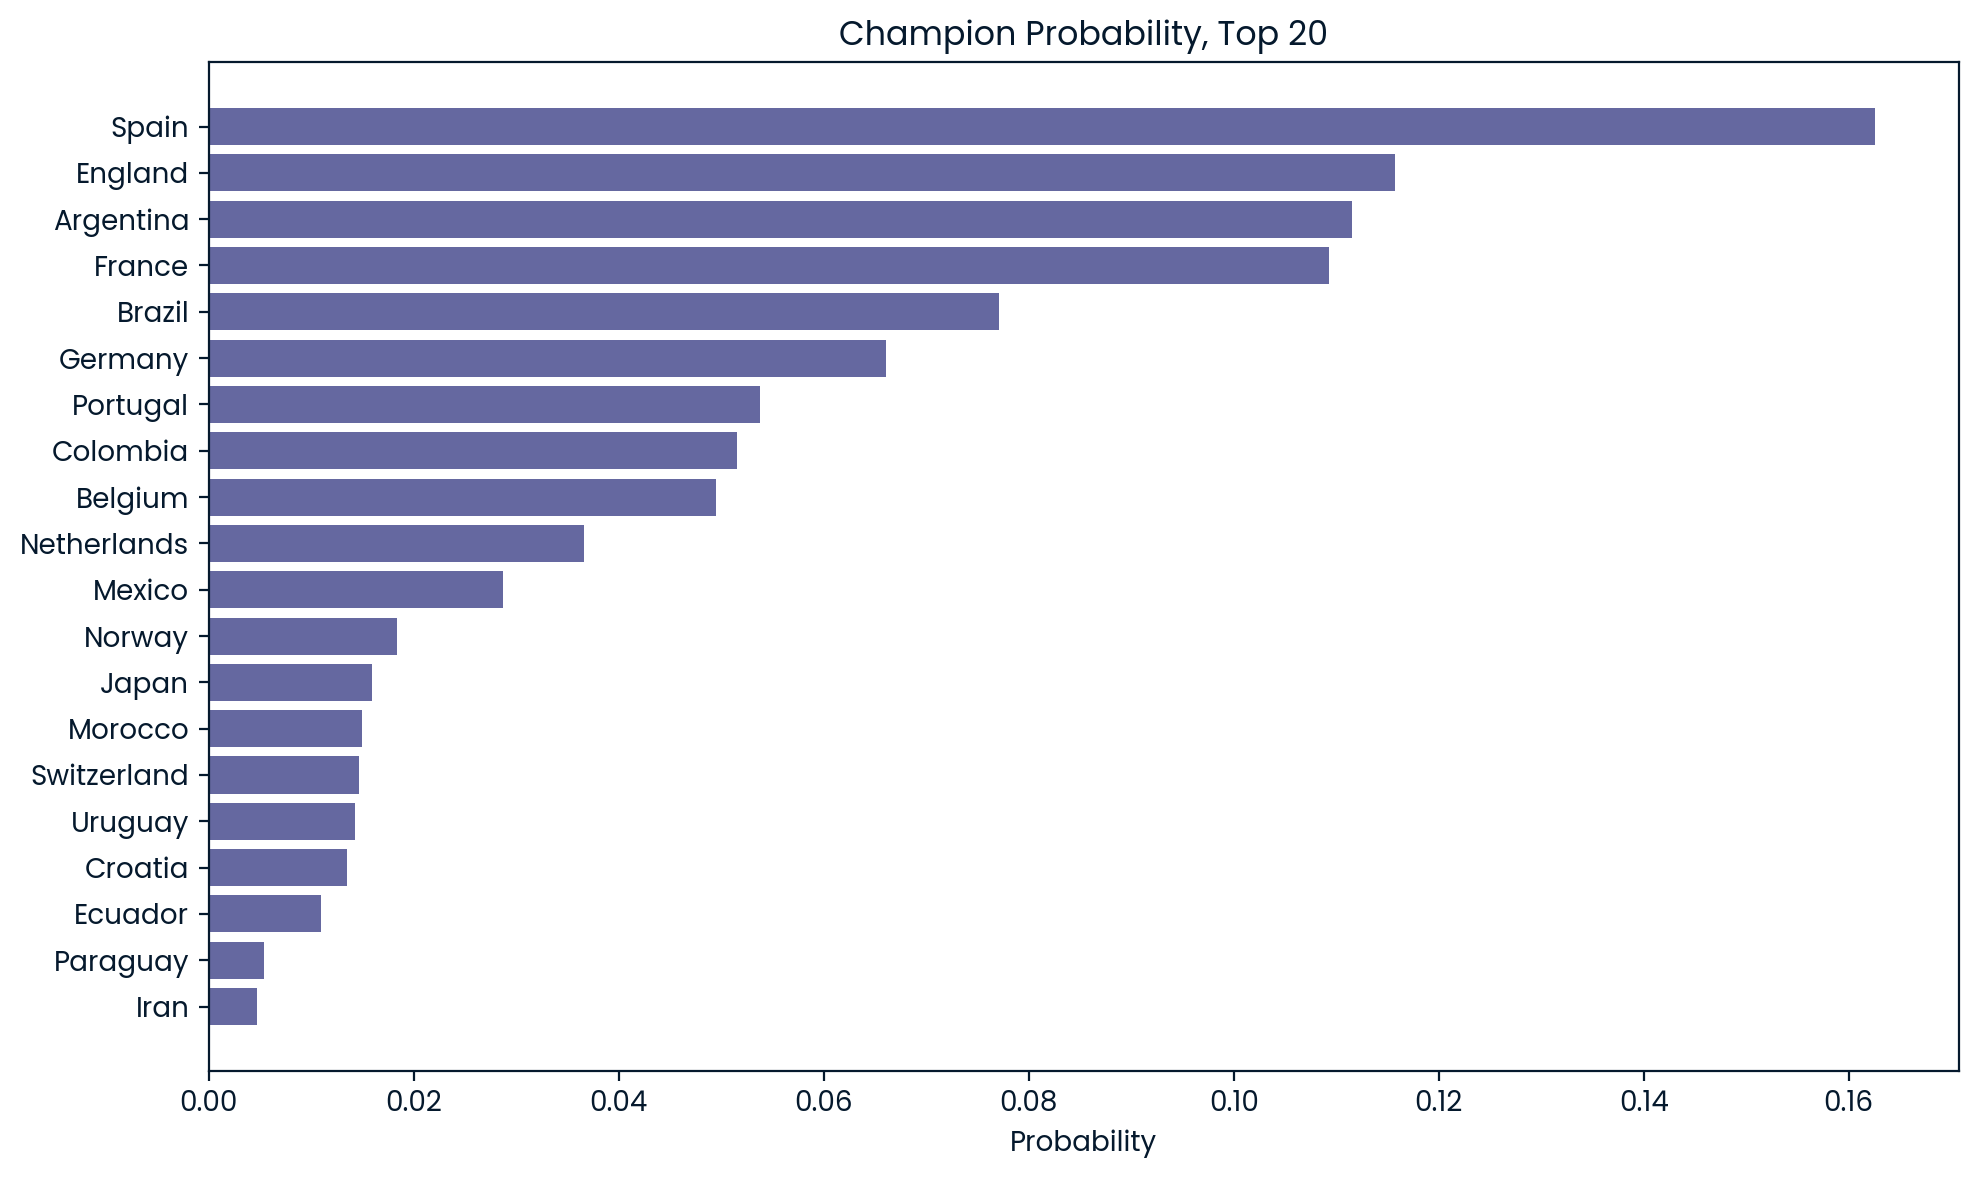

In [15]:
rank_plot_df = fixture_team_features.reset_index()
fig = px.histogram(rank_plot_df, x="rank", nbins=25, title="FIFA Ranking Distribution for 2026 Fixture Teams", labels={"rank": "FIFA ranking, lower is better"})
fig.show()

top_strength = rank_plot_df.sort_values("team_strength_score", ascending=False).head(24)
fig = px.bar(top_strength.sort_values("team_strength_score"), x="team_strength_score", y="team", orientation="h", title="Top Team Strength Scores", labels={"team_strength_score": "Strength score", "team": "Team"})
fig.show()

goal_chart = group_predictions.copy()
goal_chart["match"] = goal_chart["home_team"] + " vs " + goal_chart["away_team"]
goal_long = goal_chart.melt(id_vars=["match", "group"], value_vars=["predicted_home_goals", "predicted_away_goals"], var_name="side", value_name="goals")
fig = px.bar(goal_long, x="match", y="goals", color="side", facet_row="group", title="Group Stage Predicted Goals", height=1200)
fig.update_xaxes(showticklabels=False)
fig.show()

progress_cols = ["round_32_prob", "round_16_prob", "quarterfinalist_prob", "semifinalist_prob", "finalist_prob", "champion_prob"]
progression_long = qualification_probabilities.head(16).melt(id_vars="team", value_vars=progress_cols, var_name="stage", value_name="probability")
fig = px.line(progression_long, x="stage", y="probability", color="team", markers=True, title="Tournament Progression Probabilities: Top Champion Candidates")
fig.show()

qual_chart = qualification_probabilities.sort_values("round_32_prob", ascending=False).head(32)
fig = px.bar(qual_chart.sort_values("round_32_prob"), x="round_32_prob", y="team", orientation="h", title="Round of 32 Qualification Probability", labels={"round_32_prob": "Probability", "team": "Team"})
fig.show()

champ_chart = qualification_probabilities.sort_values("champion_prob", ascending=False).head(20)
fig = px.bar(champ_chart.sort_values("champion_prob"), x="champion_prob", y="team", orientation="h", title="Champion Probability", labels={"champion_prob": "Probability", "team": "Team"})
fig.show()


def extract_feature_importance(ensemble, feature_names, top_n=25):
    importance = np.zeros(len(feature_names), dtype=float)
    total_weight = 0.0
    for _, weight, pipeline in ensemble:
        model = pipeline[-1]
        if hasattr(model, "feature_importances_"):
            values = np.asarray(model.feature_importances_, dtype=float)
            if len(values) == len(feature_names):
                importance += weight * values
                total_weight += weight
    if total_weight == 0:
        return pd.DataFrame(columns=["feature", "importance"])
    importance = importance / total_weight
    return pd.DataFrame({"feature": feature_names, "importance": importance}).sort_values("importance", ascending=False).head(top_n)


importance_df = extract_feature_importance(home_goal_ensemble, feature_cols)
if not importance_df.empty:
    fig = px.bar(importance_df.sort_values("importance"), x="importance", y="feature", orientation="h", title="Home Goals Model Feature Importance")
    fig.show()
else:
    print("Feature importance unavailable for the selected home-goals ensemble models.")

plt.figure(figsize=(10, 6))
plot_df = champ_chart.sort_values("champion_prob")
plt.barh(plot_df["team"], plot_df["champion_prob"])
plt.title("Champion Probability, Top 20")
plt.xlabel("Probability")
plt.tight_layout()
plt.show()

## 16. Final Competition Submission

The final cells write submission-ready outputs and validate that no required fields are missing.

In [16]:
group_output = group_predictions[required_group_cols].copy()
knockout_output = knockout_predictions[required_knockout_cols].copy()

for col in ["predicted_home_goals", "predicted_away_goals", "corners", "yellow_cards", "red_cards"]:
    group_output[col] = group_output[col].astype(int)
    knockout_output[col] = knockout_output[col].astype(int)
knockout_output["penalties"] = knockout_output["penalties"].astype(bool)

group_output = group_output.fillna({"winner": "draw", "venue": "Unknown"})
knockout_output = knockout_output.fillna({"match_winner": "home", "venue": "Unknown", "predicted_home_team": "Unknown", "predicted_away_team": "Unknown"})

assert not group_output.isna().any().any(), "group_output contains null values"
assert not knockout_output.isna().any().any(), "knockout_output contains null values"
assert set(group_output["winner"].unique()).issubset({"home", "away", "draw"})
assert set(knockout_output["match_winner"].unique()).issubset({"home", "away"})

group_predictions_path = OUTPUT_DIR / "group_predictions.csv"
knockout_predictions_path = OUTPUT_DIR / "knockout_predictions.csv"
progression_path = OUTPUT_DIR / "tournament_progression_probabilities.csv"

group_output.to_csv(group_predictions_path, index=False)
knockout_output.to_csv(knockout_predictions_path, index=False)
qualification_probabilities.to_csv(progression_path, index=False)

print(f"Saved {group_predictions_path}")
print(f"Saved {knockout_predictions_path}")
print(f"Saved {progression_path}")

print("Final group_predictions dataframe:")
display(group_output)
print("Final knockout_predictions dataframe:")
display(knockout_output)

Saved /work/files/workspace/outputs/group_predictions.csv
Saved /work/files/workspace/outputs/knockout_predictions.csv
Saved /work/files/workspace/outputs/tournament_progression_probabilities.csv
Final group_predictions dataframe:


,match_id,group,home_team,away_team,date_utc,venue,predicted_home_goals,predicted_away_goals,corners,yellow_cards,red_cards,winner
0,1,A,Mexico,South Africa,2026-06-11 19:00:00,"Estadio Azteca, Mexico City",3,1,10,4,0,home
1,2,A,South Korea,UEFA Playoff D,2026-06-12 02:00:00,"Estadio Akron, Guadalajara",2,1,10,3,0,home
2,3,B,Canada,UEFA Playoff A,2026-06-12 19:00:00,"BMO Field, Toronto",2,1,10,3,0,home
3,4,D,USA,Paraguay,2026-06-13 01:00:00,"SoFi Stadium, Los Angeles",2,1,10,3,0,home
4,5,D,Australia,UEFA Playoff C,2026-06-13 04:00:00,"BC Place, Vancouver",2,1,10,2,0,home
...,...,...,...,...,...,...,...,...,...,...,...,...
67,68,L,Croatia,Ghana,2026-06-27 21:00:00,"Lincoln Financial Field, Philadelphia",2,1,10,3,0,home
68,69,K,Colombia,Portugal,2026-06-27 23:30:00,"Hard Rock Stadium, Miami",1,2,11,3,0,away
69,70,K,FIFA Playoff 1,Uzbekistan,2026-06-27 23:30:00,"Mercedes-Benz Stadium, Atlanta",1,2,10,2,0,away
70,71,J,Algeria,Austria,2026-06-28 02:00:00,"GEHA Field at Arrowhead Stadium, Kansas City",1,1,11,3,0,draw


Final knockout_predictions dataframe:


,match_id,round,date_utc,venue,predicted_home_team,predicted_away_team,predicted_home_goals,predicted_away_goals,corners,yellow_cards,red_cards,match_winner,penalties
0,73,Round of 32,2026-06-28 19:00:00,"SoFi Stadium, Los Angeles",South Korea,Canada,1,1,10,3,0,home,True
1,74,Round of 32,2026-06-29 17:00:00,"NRG Stadium, Houston",Brazil,Japan,1,1,11,4,0,home,True
2,75,Round of 32,2026-06-29 20:30:00,"Gillette Stadium, Boston",Germany,Scotland,1,1,11,3,0,home,True
3,76,Round of 32,2026-06-30 01:00:00,"Estadio BBVA, Monterrey",Netherlands,Morocco,1,1,11,2,0,home,True
4,77,Round of 32,2026-06-30 17:00:00,"AT&T Stadium, Dallas",Ecuador,Norway,1,1,11,3,0,away,True
5,78,Round of 32,2026-06-30 21:00:00,"MetLife Stadium, East Rutherford",France,Egypt,2,2,11,2,0,home,True
6,79,Round of 32,2026-07-01 01:00:00,"Estadio Azteca, Mexico City",Mexico,Senegal,1,1,10,4,0,home,True
7,80,Round of 32,2026-07-01 16:00:00,"Mercedes-Benz Stadium, Atlanta",England,Uzbekistan,2,2,11,3,0,home,True
8,81,Round of 32,2026-07-01 20:00:00,"Lumen Field, Seattle",Belgium,UEFA Playoff D,2,2,11,3,0,home,True
9,82,Round of 32,2026-07-02 00:00:00,"Levi's Stadium, Santa Clara",USA,UEFA Playoff A,2,2,11,3,0,home,True


## 17. Reproducibility Notes

- `RANDOM_SEED` controls model randomness and simulation randomness.
- `N_SIMULATIONS` is set to 10,000.
- Downloaded public datasets are cached under `data/external`.
- Playoff placeholders are treated as teams with synthetic priors, so the final outputs contain no missing values.
- Corners use Football-Data.co.uk calibration when available; otherwise, the model uses a conservative football-event proxy because international corner data is not consistently public in the selected sources.
- The final output files are `outputs/group_predictions.csv` and `outputs/knockout_predictions.csv`.